# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/data/home_tasks/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

Mounted at /content/drive



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [4]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

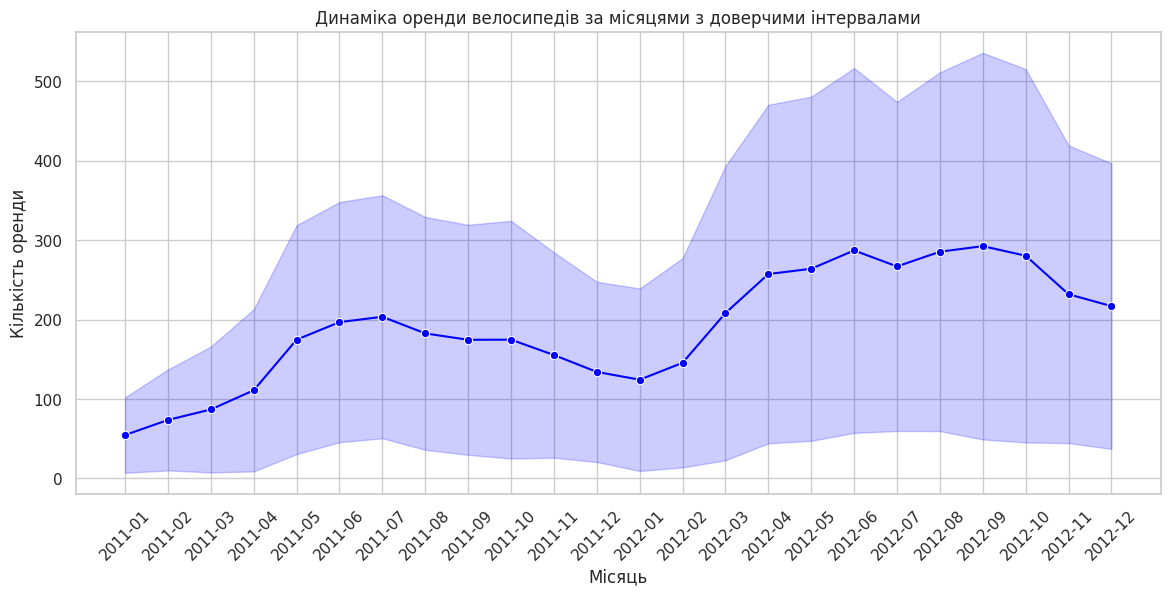

In [7]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=df,
    x='month_year',
    y='count',
    estimator='mean',
    errorbar='sd',
    marker='o',
    color='blue'
)

plt.title('Динаміка оренди велосипедів за місяцями з доверчими інтервалами')

plt.xlabel('Місяць')

plt.ylabel('Кількість оренди')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

Найбільша невизначеність спостерігається в літні місяці, особливо з червня по вересень. Довірчі інтервали у цей період є найширшими, це значить, що дані у цей період сильно коливаються і значення менш точні. Це пов'язано з тим, що погодні умови змінюються, зростає кількість оренд на велосипеди,а це призводить до більшої варіативності.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

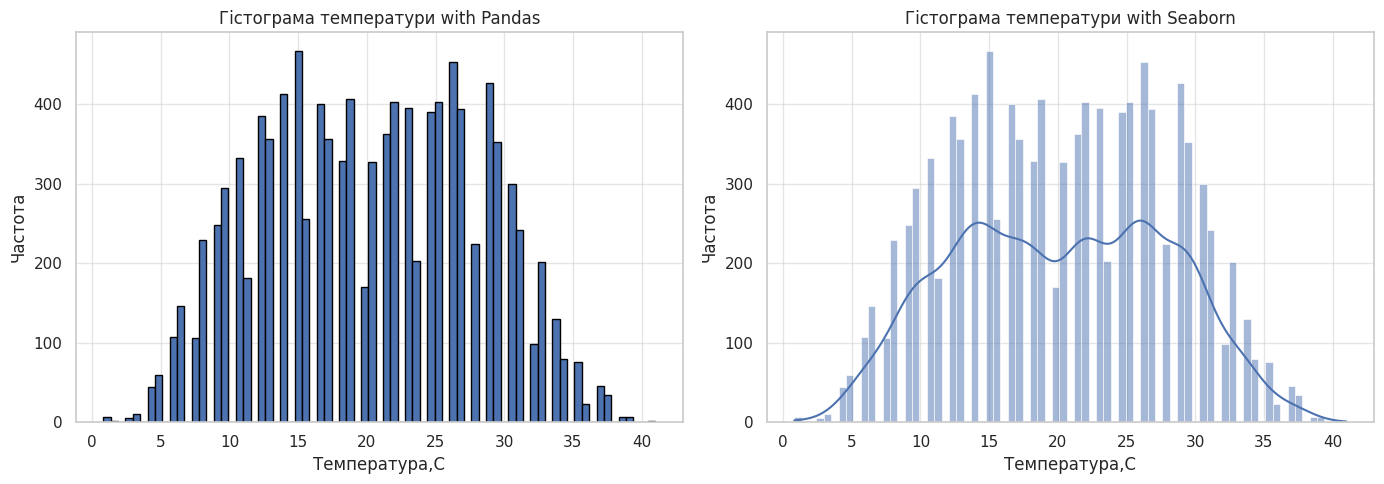

In [13]:
bins = 75

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

#Pandas histogram
df['temp'].plot(
    kind='hist',
    bins=bins,
    ax=ax[0],
    edgecolor='black',
    title='Гістограма температури with Pandas'
)
ax[0].set_xlabel('Температура,C')
ax[0].set_ylabel('Частота')
ax[0].grid(True, alpha=0.5)

#Seaborn histogram
sns.histplot(
    data=df,
    x='temp',
    bins=bins,
    kde=True,
    ax=ax[1]
)
ax[1].set_title('Гістограма температури with Seaborn')
ax[1].set_xlabel('Температура,C')
ax[1].set_ylabel('Частота')
ax[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

Гістограма Pandas показує лише стовпчики частоти значень, а гістограма Seaborn додатково має плавну лінію розподілу, тому виглядає більш інформативною.Додаткова лінія на графіку в Seaborn-це лінія KDE, вона показує плавний розподіл даних.Завдяки ній ми можемо побачити при яких температурах значення зустрічаються найчастіше.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

In [14]:
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

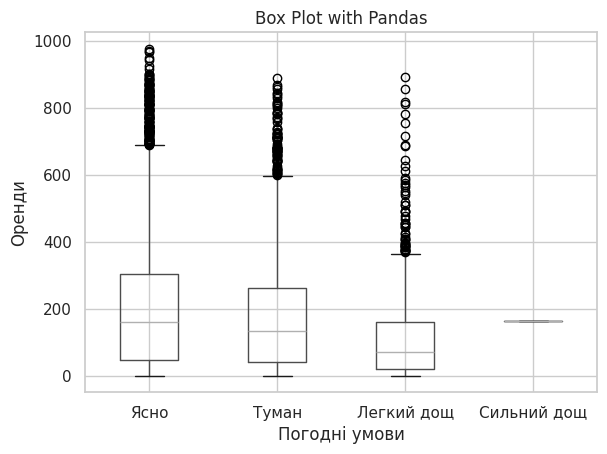

In [24]:
#Pandas boxplot

df.boxplot(column='count', by='weather')

plt.title('Box Plot with Pandas')
plt.suptitle('')

plt.xlabel('Погодні умови')
plt.ylabel('Оренди')

plt.xticks(
    ticks=[1,2,3,4],
    labels=[weather_labels[i] for i in [1,2,3,4]]
)

plt.grid(True)

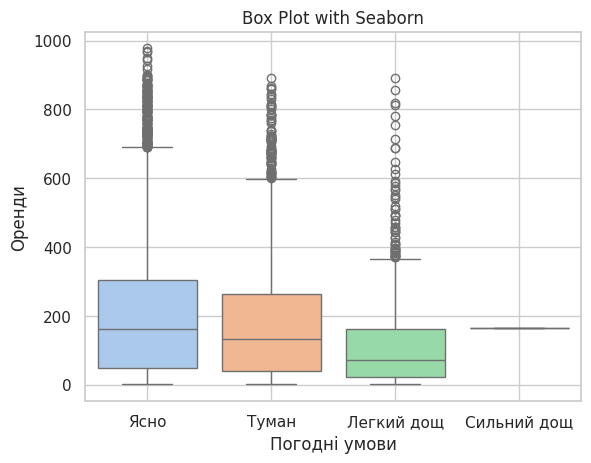

In [25]:
sns.boxplot(
    data=df,
    x='weather',
    y='count',
    hue='weather',
    palette='pastel',
    legend=False
)

plt.title('Box Plot with Seaborn')

plt.xlabel('Погодні умови')
plt.ylabel('Оренди')

plt.xticks(
    ticks=[0,1,2,3],
    labels=[weather_labels[i] for i in [1,2,3,4]]
)

plt.grid(True)


plt.show()

Box plot, побудований за допомогою Pandas має більш простий вигляд, із Seaborn має більш красивий вигляд і краще підходить для візуалізації.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


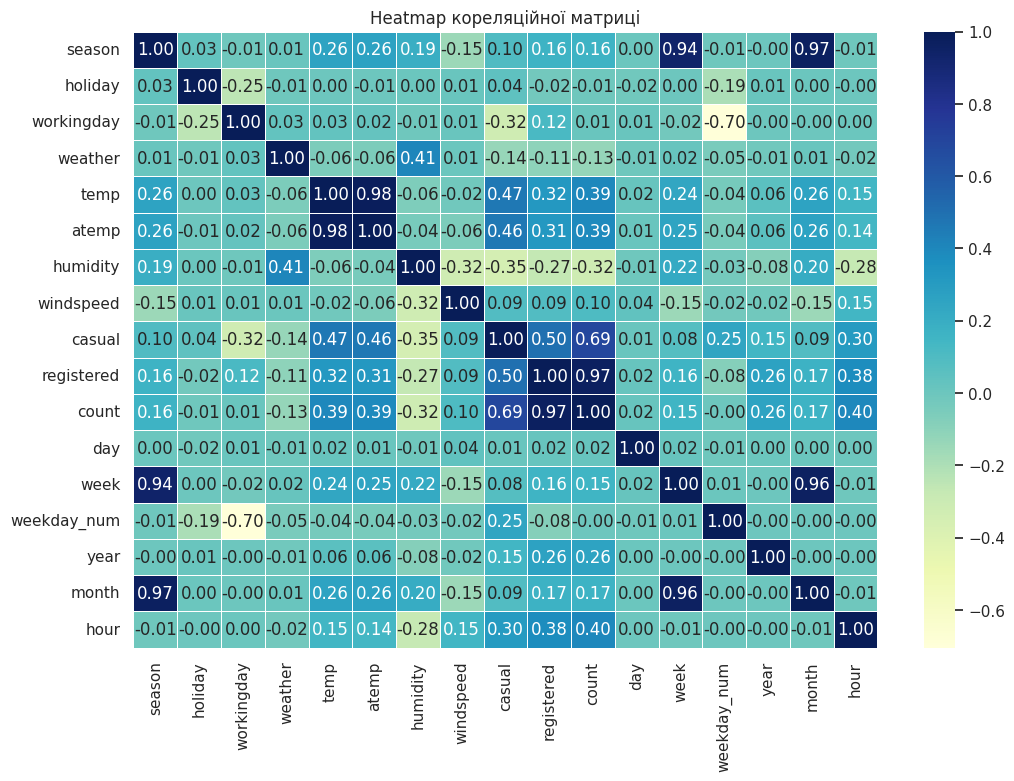

In [29]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Heatmap кореляційної матриці')

plt.show()

Найсильнішу позитивну кореляцію за кількістю оренд (count) мають

registered (0.97), casual (0.69).Кореляція між temp та atemp складає 0.98. Бо вони майже однакові, тому і рахуються разом. Негативну кореляцію мають:
humidity(-0.32), weather ( -0.13), windspeed (-0.10).

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


/tmp/ipython-input-189/3461810325.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


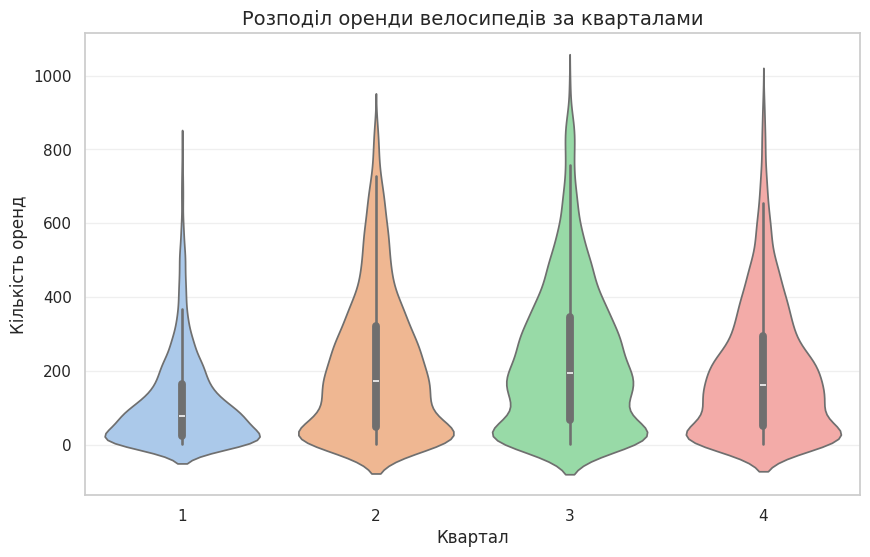

In [35]:
df['quarter'] = df.index.quarter
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='quarter',
    y='count',
    palette='pastel'
)

plt.title('Розподіл оренди велосипедів за кварталами', fontsize=14)
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')

plt.grid(axis='y', alpha=0.3)

plt.show()

Товщина violin plot показує щільність даних.Найбільша варіабельність оренди велосипедів у 3 кварталі.Violin plot показує більше інформації, ніж box plot.
Violin plot показує де значення зустрічаються найчастіше, щільність даних.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

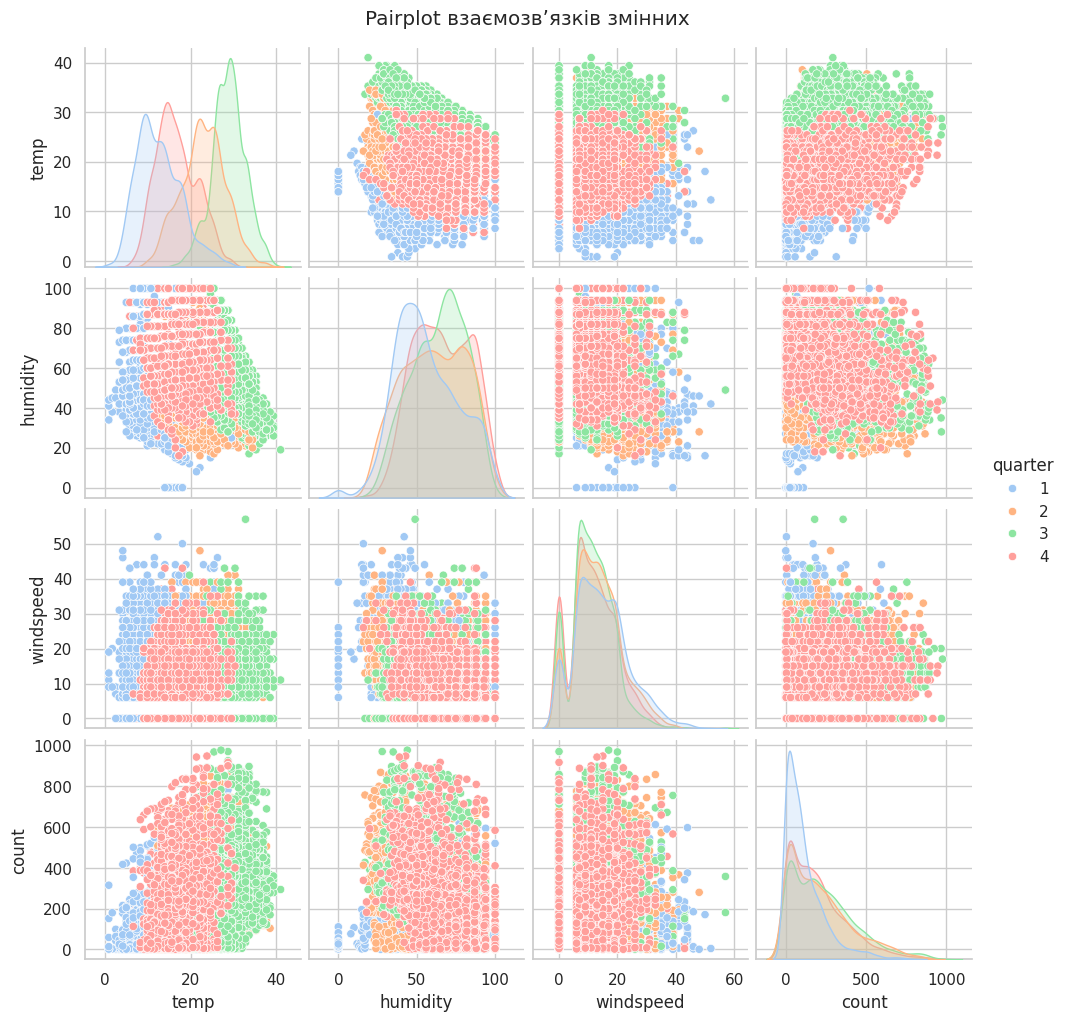

In [36]:
df['quarter'] = df.index.quarter
sns.pairplot(
    df[['temp', 'humidity', 'windspeed', 'count', 'quarter']],
    hue='quarter',
    palette='pastel',
    diag_kind='kde'
)

plt.suptitle('Pairplot взаємозвʼязків змінних', y=1.02)

plt.show()

Найсильніший лінійний зв'язок спостерігається між температурою та кількістю оренд велосипедів. Це означає, що зі збільшенням температури збільшується кількість оренд на велосипеди. Між кварталами відрізняється температура, оскільки на це вприває сезонні зміни погоди.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

<Figure size 800x600 with 0 Axes>

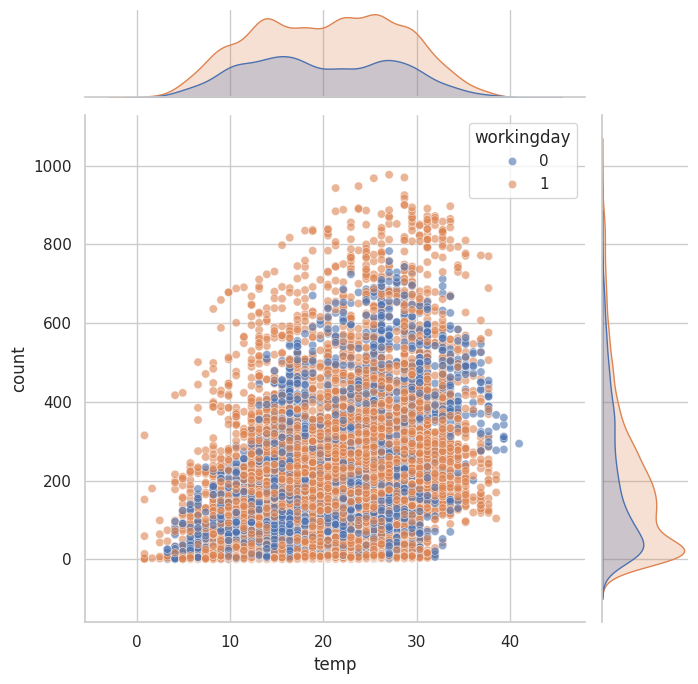

In [37]:
plt.figure(figsize=(8,6))

sns.jointplot(
    data=df,
    x='temp',
    y='count',
    hue='workingday',
    height=7,
    alpha=0.6
)

plt.show()

Графіки по краях показують розподіл температури та кількості оренд окремо.
Так, є різниця у поведінці користувачів у робочі та неробочі дні. У робочі дні кількість оренд на велосипеди більша, це пов'язано із тим, що у ці дні люди активно користуються цим видом транспорту для поїздки на роботу та навчання.